# 1.5.10 Feature Matching + Homography to find Objects

In [1]:
import cv2
import numpy as np
from matplotlib import pyplot as plt

In [ ]:
MIN_MATCH_COUNT = 10
img1 = cv2.imread('BOOK.jpg',0) # queryImage
img2 = cv2.imread('dus1.jpg',0) # trainImage

In [11]:
# Initiate SIFT detector
sift = cv2.SIFT_create()
# find the keypoints and descriptors with SIFT
kp1, des1 = sift.detectAndCompute(img1,None)
kp2, des2 = sift.detectAndCompute(img2,None)

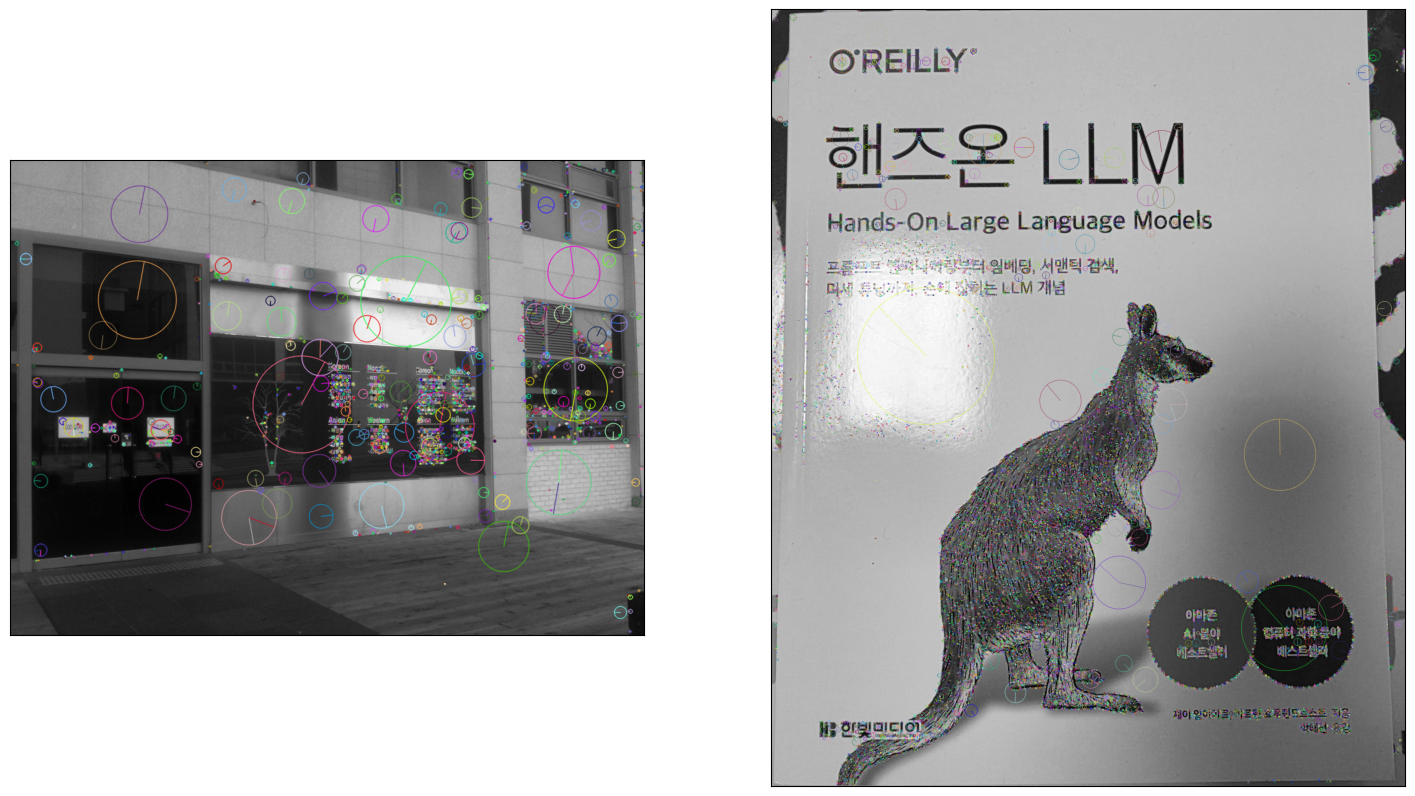

In [12]:
img1v = cv2.drawKeypoints(img1, kp1, img1, flags=cv2.DRAW_MATCHES_FLAGS_DRAW_RICH_KEYPOINTS) #,flags=cv2.DRAW_MATCHES_FLAGS_DRAW_RICH_KEYPOINTS
img2v = cv2.drawKeypoints(img2, kp2, img2, flags=cv2.DRAW_MATCHES_FLAGS_DRAW_RICH_KEYPOINTS)
plt.figure(figsize = (18,18))
plt.subplot(1,2,1), plt.imshow(img1v), plt.xticks([]), plt.yticks([])
plt.subplot(1,2,2), plt.imshow(img2v), plt.xticks([]), plt.yticks([])
plt.show()

In [13]:
FLANN_INDEX_KDTREE = 0
index_params = dict(algorithm = FLANN_INDEX_KDTREE, trees = 5)
search_params = dict(checks = 50)
flann = cv2.FlannBasedMatcher(index_params, search_params)
matches = flann.knnMatch(des1,des2,k=2)

In [14]:
# store all the good matches as per Lowe's ratio test.
good = []
for m,n in matches:
    if m.distance < 0.5*n.distance:
        good.append(m)

In [15]:
print(len(good))

0


In [16]:
if len(good)>MIN_MATCH_COUNT:
    src_pts = np.float32([ kp1[m.queryIdx].pt for m in good ]).reshape(-1,1,2)
    dst_pts = np.float32([ kp2[m.trainIdx].pt for m in good ]).reshape(-1,1,2)
    M, mask = cv2.findHomography(src_pts, dst_pts, cv2.RANSAC,5.0)
    matchesMask = mask.ravel().tolist()
    h,w = img1.shape
    pts = np.float32([ [0,0],[0,h-1],[w-1,h-1],[w-1,0] ]).reshape(-1,1,2)
    dst = cv2.perspectiveTransform(pts,M)
    img2 = cv2.polylines(img2,[np.int32(dst)],True,255,3, cv2.LINE_AA)
else:
    print("Not enough matches are found - %d/%d" % (len(good),MIN_MATCH_COUNT))
    matchesMask = None

Not enough matches are found - 0/10


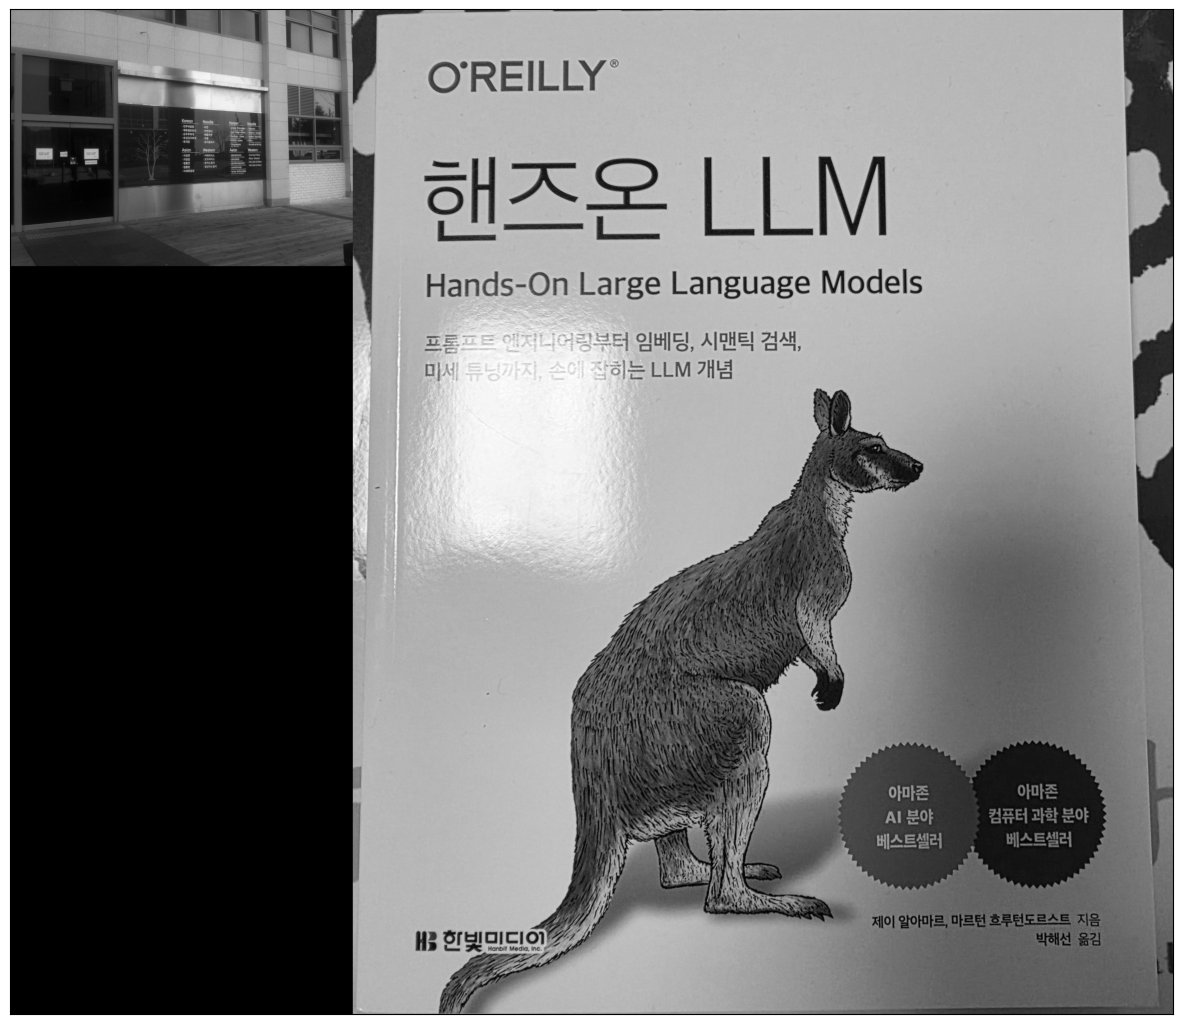

(<matplotlib.image.AxesImage at 0x1d08614a990>, ([], []), ([], []), None)

In [17]:
draw_params = dict(matchColor = (0,255,0), singlePointColor = None, matchesMask = matchesMask, flags = 2)
img3 = cv2.drawMatches(img1,kp1,img2,kp2,good,None,**draw_params)
plt.figure(figsize = (15,15))
plt.imshow(img3, 'gray'), plt.xticks([]), plt.yticks([]), plt.show()

In [ ]:
cap = cv2.VideoCapture(0)
while(True):
    ret, frame = cap.read()
    gray = cv2.cvtColor(frame, cv2.COLOR_BGR2GRAY)
    kp2, des2 = sift.detectAndCompute(gray,None)
    img2v = cv2.drawKeypoints(frame, kp2, frame, flags=cv2.DRAW_MATCHES_FLAGS_DRAW_RICH_KEYPOINTS)
    
    if len(kp2) > 10:
        matches = flann.knnMatch(des1,des2,k=2)
        good = []
        for m,n in matches:
            if m.distance < 0.5*n.distance:
                good.append(m)
        if len(good)>MIN_MATCH_COUNT:
            src_pts = np.float32([ kp1[m.queryIdx].pt for m in good ]).reshape(-1,1,2)
            dst_pts = np.float32([ kp2[m.trainIdx].pt for m in good ]).reshape(-1,1,2)
            M, mask = cv2.findHomography(src_pts, dst_pts, cv2.RANSAC,5.0)
            matchesMask = mask.ravel().tolist()
            h,w = img1.shape
            pts = np.float32([ [0,0],[0,h-1],[w-1,h-1],[w-1,0] ]).reshape(-1,1,2)
            dst = cv2.perspectiveTransform(pts,M) #기울어진거 반듯하게 하는 거
            frame = cv2.polylines(frame,[np.int32(dst)],True,255,3, cv2.LINE_AA)
        else:
            print("Not enough matches are found - %d/%d" % (len(good),MIN_MATCH_COUNT))
            matchesMask = None
    img3 = cv2.drawMatches(img1,kp1,frame,kp2,good,None) #good 뒤에 [:20] 붙여서 개수 제한을 걸 수 있음
    cv2.imshow('frame',img3)

    if cv2.waitKey(1) & 0xFF == ord('q'):
        break
cap.release()
cv2.destroyAllWindows()

Not enough matches are found - 6/10
Not enough matches are found - 6/10


error: OpenCV(4.13.0) D:\a\opencv-python\opencv-python\opencv\modules\features2d\src\draw.cpp:242: error: (-215:Assertion failed) i2 >= 0 && i2 < static_cast<int>(keypoints2.size()) in function 'cv::drawMatches'


: 

In [9]:
import cv2
import numpy as np
from matplotlib import pyplot as plt

img1 = cv2.imread("dsu2.jpg", cv2.IMREAD_GRAYSCALE)
img2 = cv2.imread("dsu1.jpg", cv2.IMREAD_GRAYSCALE)

orb = cv2.ORB_create()
kp1, des1 = orb.detectAndCompute(img1, None)
kp2, des2 = orb.detectAndCompute(img2, None)

bf = cv2.BFMatcher(cv2.NORM_HAMMING, crossCheck=True)
matches = bf.match(des1, des2)
matches = sorted(matches, key = lambda x:x.distance)

matching_result = cv2.drawMatches(img1, kp1, img2, kp2, matches[:20], None, flags=2)

cv2.imshow("img1", img1)
cv2.imshow("img2", img2)
cv2.imshow("matching_result", matching_result)
cv2.waitKey(0)
cv2.destroyAllWindows()
